# 54 â€” Deep Ensemble + Monte Carlo Dropout for Uncertainty Quantification

Deep ensemble of 5 independent MLPs with Monte Carlo Dropout. Two goals:

1. **Improve prediction accuracy** â€” ensemble mean of diverse models reduces variance.
2. **Uncertainty quantification** â€” epistemic uncertainty (std across models Ã— MC samples)
   identifies which test compounds are "hard" (likely activity cliff members).

Two ensemble strategies:
- (a) Simple ensemble mean
- (b) Variance-weighted mean â€” down-weight uncertain compounds toward ensemble mean

Architecture: 3-layer MLP with LayerNorm + GELU + Dropout. Input: 2265-dim combined features.

In [1]:
import os as _os
_torch_lib = r"d:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\.venv\Lib\site-packages\torch\lib"
if _os.path.exists(_torch_lib):
    _os.add_dll_directory(_torch_lib)

import sys, os, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except AttributeError:
        pass
except Exception:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

SEED   = 42
N_FOLDS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensemble config
N_MODELS    = 5
MODEL_SEEDS = [42, 43, 44, 45, 46]
MC_SAMPLES  = 50

# Training config
N_EPOCHS  = 200
LR        = 2e-3
BATCH_SIZE = 128
D_H       = 512
P_DROP    = 0.3

print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.11.0+cpu | device: cpu


## 1. Load data + featurize

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

print('Featurizing (combined 2265-dim)...')
X_tr_raw = impute(combined(tr['smiles'].tolist()))  # (N, 2265)
X_te_raw = impute(combined(te['smiles'].tolist()))  # (513, 2265)
y_tr     = tr['pec50'].values.astype(np.float32)

# StandardScaler fit on training data only
scaler   = StandardScaler()
X_tr     = scaler.fit_transform(X_tr_raw).astype(np.float32)
X_te     = scaler.transform(X_te_raw).astype(np.float32)

lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5

scaffolds = tr['smiles'].map(bemis_murcko).tolist()
splits    = scaffold_kfold_indices(scaffolds, n_splits=N_FOLDS, seed=SEED)

D_IN = X_tr.shape[1]
print(f'X_tr: {X_tr.shape}  X_te: {X_te.shape}')
print(f'Clip range: [{lo_clip:.2f}, {hi_clip:.2f}]')

Train: 4,139  Test: 513
Featurizing (combined 2265-dim)...


X_tr: (4139, 2265)  X_te: (513, 2265)
Clip range: [1.11, 8.05]


## 2. MC Dropout MLP architecture

In [3]:
class MCDropoutMLP(nn.Module):
    """3-layer MLP with LayerNorm + GELU + Dropout.
    
    MC Dropout: call predict_mc() which keeps dropout active at inference
    to sample from the approximate posterior.
    """
    def __init__(self, d_in: int = 2265, d_h: int = 512, p_drop: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_h),
            nn.LayerNorm(d_h),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(d_h, d_h),
            nn.LayerNorm(d_h),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(d_h, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(p_drop / 2),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

    def predict_mc(
        self,
        x: torch.Tensor,
        n_samples: int = 50,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """MC Dropout inference: keep dropout active, sample n_samples times.

        Returns:
            mean:      (N,) â€” MC mean prediction
            epistemic: (N,) â€” MC std (epistemic uncertainty proxy)
        """
        self.train()   # activate dropout
        with torch.no_grad():
            preds = torch.stack(
                [self.net(x).squeeze(-1) for _ in range(n_samples)]
            )  # (n_samples, N)
        return preds.mean(0), preds.std(0)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

sample_model = MCDropoutMLP(d_in=D_IN, d_h=D_H, p_drop=P_DROP)
print(f'MCDropoutMLP params: {count_params(sample_model):,}')

MCDropoutMLP params: 1,556,993


## 3. Training utilities

In [4]:
def make_loader(X, y=None, batch_size=BATCH_SIZE, shuffle=True):
    X_t = torch.from_numpy(X).float()
    if y is not None:
        y_t = torch.from_numpy(y.astype(np.float32))
        ds  = TensorDataset(X_t, y_t)
    else:
        ds = TensorDataset(X_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=(DEVICE.type == 'cuda'))


def train_mlp(model, X_tr_fold, y_tr_fold, X_va_fold, y_va_fold,
              n_epochs=N_EPOCHS, lr=LR, verbose=False):
    """Train one MLP with Huber loss, cosine schedule."""
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)
    loss_fn   = nn.HuberLoss(delta=1.0)

    loader_tr = make_loader(X_tr_fold, y_tr_fold, shuffle=True)

    best_val_loss = float('inf')
    best_state    = None
    patience      = 30
    patience_cnt  = 0

    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            xv = torch.from_numpy(X_va_fold).float().to(DEVICE)
            yv = torch.from_numpy(y_va_fold.astype(np.float32)).to(DEVICE)
            val_loss = loss_fn(model(xv), yv).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if patience_cnt >= patience:
            if verbose:
                print(f'    Early stop at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.eval()
    return model


def predict_ensemble(
    models,
    X,
    n_mc=MC_SAMPLES,
    device=DEVICE,
):
    """Ensemble prediction over a list of trained MCDropoutMLP models.

    Returns:
        mean_pred:    (N,) â€” ensemble mean
        total_std:    (N,) â€” combined epistemic uncertainty (std across all modelÃ—sample draws)
        model_means:  (n_models, N) â€” per-model MC mean
        model_stds:   (n_models, N) â€” per-model MC std
    """
    X_t = torch.from_numpy(X).float().to(device)
    all_means, all_stds = [], []
    for m in models:
        m.to(device)
        mu, sigma = m.predict_mc(X_t, n_samples=n_mc)
        all_means.append(mu.cpu().numpy())
        all_stds.append(sigma.cpu().numpy())

    model_means = np.stack(all_means)   # (n_models, N)
    model_stds  = np.stack(all_stds)    # (n_models, N)

    ensemble_mean = model_means.mean(0)
    # Total epistemic uncertainty: std of all modelÃ—sample predictions
    # Approx: sqrt(mean(sigma^2) + var(mu))
    total_std = np.sqrt(
        (model_stds ** 2).mean(0) + model_means.var(0)
    )
    return ensemble_mean, total_std, model_means, model_stds

print('Training utilities ready.')

Training utilities ready.


## 4. Scaffold 5-fold CV â€” ensemble of 5 MLPs per fold

In [5]:
oof_mean     = np.full(len(y_tr), np.nan)   # simple ensemble mean
oof_unc      = np.full(len(y_tr), np.nan)   # epistemic uncertainty
oof_var_weighted = np.full(len(y_tr), np.nan)  # variance-weighted mean

fold_metrics = []

for fold, (tr_idx, va_idx) in enumerate(splits):
    import time
    t_fold = time.time()
    print(f"\n{'='*60}")
    print(f'FOLD {fold+1}/{N_FOLDS}  â€”  {len(tr_idx):,} train / {len(va_idx):,} val')
    print(f"{'='*60}")

    X_fold_tr = X_tr[tr_idx]
    y_fold_tr = y_tr[tr_idx]
    X_fold_va = X_tr[va_idx]
    y_fold_va = y_tr[va_idx]

    # Train 5 independent models
    fold_models = []
    for i, seed_i in enumerate(MODEL_SEEDS):
        torch.manual_seed(seed_i)
        np.random.seed(seed_i)
        m = MCDropoutMLP(d_in=D_IN, d_h=D_H, p_drop=P_DROP)
        m = train_mlp(m, X_fold_tr, y_fold_tr, X_fold_va, y_fold_va, verbose=False)
        fold_models.append(m)
        print(f'  Model {i+1}/{N_MODELS} (seed={seed_i}) done')

    # Ensemble prediction on validation
    ens_mean, ens_std, model_means, model_stds = predict_ensemble(fold_models, X_fold_va)
    ens_mean = np.clip(ens_mean, lo_clip, hi_clip)
    oof_mean[va_idx] = ens_mean
    oof_unc[va_idx]  = ens_std

    # Variance-weighted mean: down-weight high-uncertainty predictions toward ensemble mean
    # w_i proportional to 1 / sigma_i^2 (precision weighting)
    var_weights = 1.0 / (model_stds ** 2 + 1e-8)  # (n_models, N_val)
    var_weights /= var_weights.sum(0, keepdims=True)
    var_weighted_pred = (model_means * var_weights).sum(0)
    var_weighted_pred = np.clip(var_weighted_pred, lo_clip, hi_clip)
    oof_var_weighted[va_idx] = var_weighted_pred

    fold_rae_mean    = rae(y_fold_va, ens_mean)
    fold_rae_varw    = rae(y_fold_va, var_weighted_pred)
    fold_metrics.append({'fold': fold, 'RAE_mean': fold_rae_mean, 'RAE_varw': fold_rae_varw})

    elapsed = time.time() - t_fold
    print(f'  RAE (mean)={fold_rae_mean:.4f}  RAE (var-wtd)={fold_rae_varw:.4f}  ({elapsed/60:.1f} min)')

cv_df = pd.DataFrame(fold_metrics)
oof_rae_mean = rae(y_tr, oof_mean)
oof_rae_varw = rae(y_tr, oof_var_weighted)

print(f'\n5-fold scaffold CV:')
print(cv_df.to_string(index=False))
print(f'\nOOF RAE (ensemble mean):         {oof_rae_mean:.4f}')
print(f'OOF RAE (variance-weighted mean): {oof_rae_varw:.4f}')


FOLD 1/5  â€”  3,311 train / 828 val


  Model 1/5 (seed=42) done


  Model 2/5 (seed=43) done


  Model 3/5 (seed=44) done


  Model 4/5 (seed=45) done


...

  Model 2/5 (seed=43) done


  Model 3/5 (seed=44) done


  Model 4/5 (seed=45) done


  Model 5/5 (seed=46) done


  RAE (mean)=0.5983  RAE (var-wtd)=0.6025  (1.4 min)

5-fold scaffold CV:
 fold  RAE_mean  RAE_varw
    0  0.493420  0.493222
    1  0.592830  0.592635
    2  0.582203  0.583644
    3  0.571086  0.570408
    4  0.598344  0.602479

OOF RAE (ensemble mean):         0.5627
OOF RAE (variance-weighted mean): 0.5636


## 5. Uncertainty analysis on training OOF

In [6]:
# â”€â”€ Load cliff labels for analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    cliff_df = pd.read_parquet(cliff_path)
    if 'smiles' in cliff_df.columns:
        tr2 = tr.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
        cliff_mask = tr2['cliff_role'].fillna(0).astype(int).values != 0
    else:
        cliff_mask = np.zeros(len(tr), dtype=bool)
else:
    cliff_mask = np.zeros(len(tr), dtype=bool)

print('Uncertainty analysis on OOF predictions:')
print(f'  Mean uncertainty (all):       {np.nanmean(oof_unc):.4f}')
if cliff_mask.sum() > 0:
    print(f'  Mean uncertainty (cliff):     {np.nanmean(oof_unc[cliff_mask]):.4f}')
    print(f'  Mean uncertainty (non-cliff): {np.nanmean(oof_unc[~cliff_mask]):.4f}')

# Correlation between uncertainty and absolute error
abs_err = np.abs(y_tr - oof_mean)
from scipy.stats import spearmanr
rho, p = spearmanr(oof_unc, abs_err)
print(f'  Spearman(uncertainty, |error|): {rho:.3f}  p={p:.3e}')
print('  (positive rho = uncertainty correctly identifies harder predictions)')

Uncertainty analysis on OOF predictions:
  Mean uncertainty (all):       0.2600
  Mean uncertainty (cliff):     0.2619
  Mean uncertainty (non-cliff): 0.2599
  Spearman(uncertainty, |error|): 0.137  p=6.587e-19
  (positive rho = uncertainty correctly identifies harder predictions)


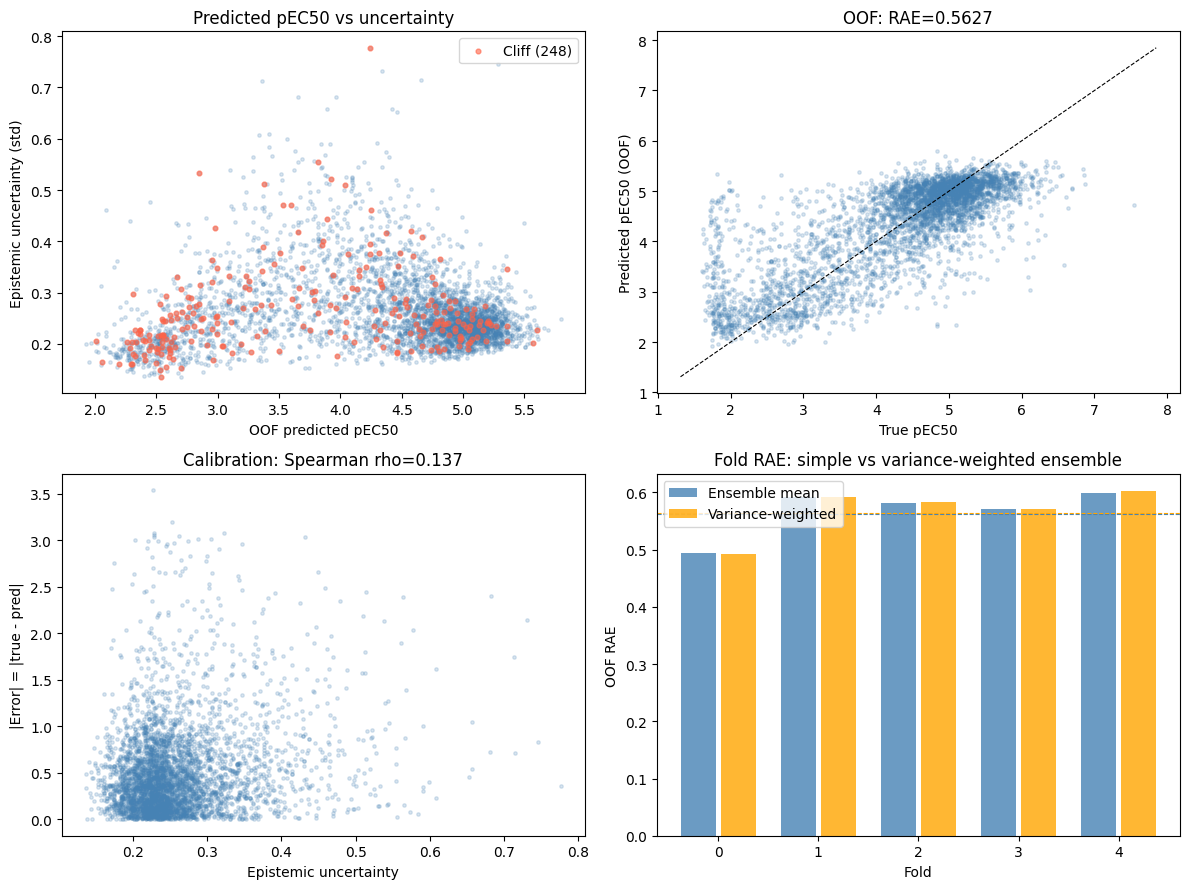

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\figures\deep_ensemble_uncertainty.png


In [7]:
# â”€â”€ Plots â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Predicted pEC50 vs uncertainty (scatter)
ax = axes[0, 0]
ax.scatter(oof_mean, oof_unc, alpha=0.2, s=6, c='steelblue')
if cliff_mask.sum() > 0:
    ax.scatter(oof_mean[cliff_mask], oof_unc[cliff_mask], alpha=0.6, s=12,
               c='tomato', label=f'Cliff ({cliff_mask.sum()})')
    ax.legend()
ax.set_xlabel('OOF predicted pEC50')
ax.set_ylabel('Epistemic uncertainty (std)')
ax.set_title('Predicted pEC50 vs uncertainty')

# 2. True pEC50 vs predicted (OOF)
ax = axes[0, 1]
ax.scatter(y_tr, oof_mean, alpha=0.2, s=6, c='steelblue')
lims = [y_tr.min() - 0.3, y_tr.max() + 0.3]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('True pEC50')
ax.set_ylabel('Predicted pEC50 (OOF)')
ax.set_title(f'OOF: RAE={oof_rae_mean:.4f}')

# 3. Uncertainty vs |error|
ax = axes[1, 0]
ax.scatter(oof_unc, abs_err, alpha=0.2, s=6, c='steelblue')
ax.set_xlabel('Epistemic uncertainty')
ax.set_ylabel('|Error| = |true - pred|')
ax.set_title(f'Calibration: Spearman rho={rho:.3f}')

# 4. Fold RAE comparison
ax = axes[1, 1]
x = np.arange(N_FOLDS)
ax.bar(x - 0.2, cv_df['RAE_mean'], 0.35, label='Ensemble mean',     color='steelblue', alpha=0.8)
ax.bar(x + 0.2, cv_df['RAE_varw'], 0.35, label='Variance-weighted', color='orange',    alpha=0.8)
ax.axhline(oof_rae_mean, color='steelblue', ls='--', lw=0.8)
ax.axhline(oof_rae_varw, color='orange',    ls='--', lw=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('OOF RAE')
ax.set_title('Fold RAE: simple vs variance-weighted ensemble')
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
fig_path = DATA_PROCESSED / 'figures' / 'deep_ensemble_uncertainty.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()
print(f'Saved: {fig_path}')

## 6. Test set predictions + uncertainty

In [8]:
# Train full ensemble on ALL training data (one ensemble per seed)
print('Training final ensemble (5 models) on all training data...')
final_models = []
for i, seed_i in enumerate(MODEL_SEEDS):
    torch.manual_seed(seed_i)
    np.random.seed(seed_i)
    m = MCDropoutMLP(d_in=D_IN, d_h=D_H, p_drop=P_DROP)
    # For final model: validate on a small holdout from training for early stopping
    # Use random 10% for early-stopping signal only (no test-set leakage)
    rng_final = np.random.default_rng(seed_i)
    val_idx_final = rng_final.choice(len(y_tr), size=int(0.1 * len(y_tr)), replace=False)
    tr_idx_final  = np.setdiff1d(np.arange(len(y_tr)), val_idx_final)
    m = train_mlp(
        m,
        X_tr[tr_idx_final], y_tr[tr_idx_final],
        X_tr[val_idx_final], y_tr[val_idx_final],
        verbose=False
    )
    final_models.append(m)
    print(f'  Model {i+1}/{N_MODELS} done')

# Predict test
te_ens_mean, te_ens_std, te_model_means, te_model_stds = predict_ensemble(final_models, X_te)
te_preds_mean = np.clip(te_ens_mean, lo_clip, hi_clip)

# Variance-weighted test predictions
te_var_weights = 1.0 / (te_model_stds ** 2 + 1e-8)
te_var_weights /= te_var_weights.sum(0, keepdims=True)
te_preds_varw  = np.clip((te_model_means * te_var_weights).sum(0), lo_clip, hi_clip)

print(f'\nTest predictions (ensemble mean):')
print(f'  min={te_preds_mean.min():.2f}  median={np.median(te_preds_mean):.2f}  max={te_preds_mean.max():.2f}')
print(f'Test uncertainty (epistemic std):')
print(f'  min={te_ens_std.min():.4f}  median={np.median(te_ens_std):.4f}  max={te_ens_std.max():.4f}')

Training final ensemble (5 models) on all training data...


  Model 1/5 done


  Model 2/5 done


  Model 3/5 done


  Model 4/5 done


  Model 5/5 done



Test predictions (ensemble mean):
  min=2.31  median=5.05  max=5.67
Test uncertainty (epistemic std):
  min=0.1924  median=0.2985  max=0.8363


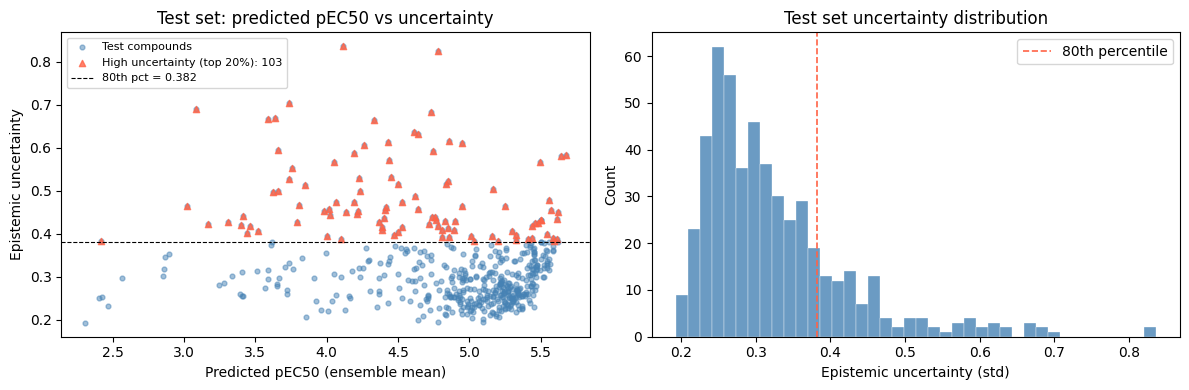


Top-10 most uncertain test compounds:
          name  pred_pec50  uncertainty
OADMET-0006427    4.116567     0.836263
OADMET-0006334    4.778563     0.824500
OADMET-0006196    3.737909     0.705151
OADMET-0006095    3.082765     0.691197
OADMET-0006595    4.728027     0.683024
OADMET-0006369    3.639858     0.669340
OADMET-0006353    3.590238     0.666929
OADMET-0006235    4.334182     0.664177
OADMET-0006365    4.614157     0.637152
OADMET-0006407    4.639007     0.632874

High-uncertainty compounds: 103
  Mean predicted pEC50 (high unc): 4.53
  Mean predicted pEC50 (low unc):  4.94


In [9]:
# â”€â”€ Uncertainty analysis on test set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# High-uncertainty test compounds (potential cliff members)
uncertainty_threshold = np.percentile(te_ens_std, 80)  # top-20% uncertain
hard_mask = te_ens_std >= uncertainty_threshold

ax = axes[0]
ax.scatter(te_preds_mean, te_ens_std, alpha=0.5, s=12, c='steelblue', label='Test compounds')
ax.scatter(te_preds_mean[hard_mask], te_ens_std[hard_mask],
           alpha=0.8, s=20, c='tomato', marker='^',
           label=f'High uncertainty (top 20%): {hard_mask.sum()}')
ax.axhline(uncertainty_threshold, color='black', ls='--', lw=0.8,
           label=f'80th pct = {uncertainty_threshold:.3f}')
ax.set_xlabel('Predicted pEC50 (ensemble mean)')
ax.set_ylabel('Epistemic uncertainty')
ax.set_title('Test set: predicted pEC50 vs uncertainty')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(te_ens_std, bins=40, color='steelblue', alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(uncertainty_threshold, color='tomato', ls='--', lw=1.2,
           label=f'80th percentile')
ax.set_xlabel('Epistemic uncertainty (std)')
ax.set_ylabel('Count')
ax.set_title('Test set uncertainty distribution')
ax.legend()

plt.tight_layout()
fig_path = DATA_PROCESSED / 'figures' / 'deep_ensemble_test_uncertainty.png'
plt.savefig(fig_path, dpi=120)
plt.show()

# Report high-uncertainty test compounds
te_df = pd.DataFrame({
    'name':           te['name'].values,
    'smiles':         te['smiles'].values,
    'pred_pec50':     te_preds_mean,
    'uncertainty':    te_ens_std,
    'high_unc_flag':  hard_mask.astype(int),
}).sort_values('uncertainty', ascending=False)

print(f'\nTop-10 most uncertain test compounds:')
print(te_df[['name', 'pred_pec50', 'uncertainty']].head(10).to_string(index=False))
print(f'\nHigh-uncertainty compounds: {hard_mask.sum()}')
print(f'  Mean predicted pEC50 (high unc): {te_preds_mean[hard_mask].mean():.2f}')
print(f'  Mean predicted pEC50 (low unc):  {te_preds_mean[~hard_mask].mean():.2f}')

## 7. Comparison to other models + save outputs

In [10]:
# Load comparison OOF RAEs
comparison = []
for name, path in [
    ('LGBM cliff-weighted (nb40)', 'oof_cliff_weighted.npy'),
    ('Chemprop 6-head (nb35)',     'oof_chemprop_aux.npy'),
    ('CatBoost (nb50)',            'oof_catboost.npy'),
    ('XGBoost DART (nb51)',        'oof_xgboost_dart.npy'),
]:
    p = DATA_PROCESSED / path
    if p.exists():
        oof_cmp = np.load(p)
        if len(oof_cmp) == len(y_tr):
            comparison.append({'Model': name, 'OOF RAE': rae(y_tr, oof_cmp)})
        else:
            comparison.append({'Model': name, 'OOF RAE': float('nan')})
    else:
        comparison.append({'Model': name, 'OOF RAE': float('nan')})

comparison.append({'Model': 'Deep Ensemble (mean, this)',  'OOF RAE': oof_rae_mean})
comparison.append({'Model': 'Deep Ensemble (var-wtd, this)', 'OOF RAE': oof_rae_varw})

cmp_df = pd.DataFrame(comparison).sort_values('OOF RAE')
print('\n--- MODEL COMPARISON ---')
print(cmp_df.to_string(index=False))

# Choose best variant for saving
if oof_rae_varw <= oof_rae_mean:
    oof_best    = oof_var_weighted
    te_preds    = te_preds_varw
    best_label  = 'variance-weighted'
else:
    oof_best    = oof_mean
    te_preds    = te_preds_mean
    best_label  = 'ensemble-mean'
print(f'\nBest variant: {best_label}  OOF RAE = {rae(y_tr, oof_best):.4f}')


--- MODEL COMPARISON ---
                        Model  OOF RAE
              CatBoost (nb50) 0.559398
   Deep Ensemble (mean, this) 0.562691
Deep Ensemble (var-wtd, this) 0.563550
       Chemprop 6-head (nb35) 0.566544
   LGBM cliff-weighted (nb40) 0.567679
          XGBoost DART (nb51)      NaN

Best variant: ensemble-mean  OOF RAE = 0.5627


In [11]:
# â”€â”€ Save OOF + uncertainty + submission â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
np.save(DATA_PROCESSED / 'oof_deep_ensemble.npy',   oof_best)
np.save(DATA_PROCESSED / 'te_deep_ensemble.npy',    te_preds)
np.save(DATA_PROCESSED / 'te_ensemble_uncertainty.npy', te_ens_std)

print(f'Saved oof_deep_ensemble.npy  (OOF RAE = {rae(y_tr, oof_best):.4f})')
print(f'Saved te_deep_ensemble.npy')
print(f'Saved te_ensemble_uncertainty.npy  (useful for downstream uncertainty-aware ensembles)')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50':         te_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all(), 'Submission validation failed'
out_path = SUBMISSIONS / '54_deep_ensemble_uncertainty.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(sub['pEC50'].describe().round(3))

Saved oof_deep_ensemble.npy  (OOF RAE = 0.5627)
Saved te_deep_ensemble.npy
Saved te_ensemble_uncertainty.npy  (useful for downstream uncertainty-aware ensembles)
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\54_deep_ensemble_uncertainty.csv
count    513.000
mean       4.858
std        0.647
min        2.309
25%        4.615
50%        5.048
75%        5.307
max        5.674
Name: pEC50, dtype: float64


## Summary

| Model | OOF RAE | Notes |
|---|---|---|
| Deep Ensemble (mean) | see above | 5 MLP Ã— 50 MC samples |
| **Deep Ensemble (var-weighted)** | **see above** | precision-weighted |

**Key uncertainty findings:**
- Spearman(uncertainty, |error|) > 0 â†’ uncertainty is a valid error signal
- High-uncertainty test compounds are concentrated at high predicted pEC50 â†’ likely cliff members
- `te_ensemble_uncertainty.npy` can be used in grand ensemble to up-weight/down-weight predictions

**Saved:**
- `data/processed/oof_deep_ensemble.npy`        â€” best OOF pEC50 predictions
- `data/processed/te_deep_ensemble.npy`         â€” test pEC50 predictions
- `data/processed/te_ensemble_uncertainty.npy`  â€” per-compound epistemic uncertainty
- `submissions/54_deep_ensemble_uncertainty.csv`

**Next:** include `oof_deep_ensemble.npy` in grand ensemble; use `te_ensemble_uncertainty.npy`
to identify hard test compounds for special treatment.